# Import


## Libraries


In [ ]:
!pip install pandas numpy joblib matplotlib seaborn pyldavis gensim bertopic sentence-transformers umap-learn hdbscan scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 112.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 59.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 18.1 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import re
import joblib
import os

from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import pyLDAvis
import pyLDAvis.gensim_models
%matplotlib inline

import gensim
import gensim.corpora as corpora
from gensim.models.coherencemodel import CoherenceModel
from gensim.models.ldamodel import LdaModel

from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN

from sklearn.metrics.pairwise import cosine_similarity

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyPacked has no __module__ attribute
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyObject has no __module__ attribute
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and sche

## Data Load

In [ ]:
df = pd.read_csv(os.path.join(os.getcwd(), 'clean.csv'))
print(f"Load Success. Row Total: {len(df)}")
df.head(5)

Load Success. Row Total: 2885


,source,comments,timestamp,text_clean,text_refined,text_for_lda,text_for_bertopic
0,maps,Siola Mall Pelayanan Publik Dinas Kependudukan...,NaN,siola mall pelayanan publik dinas kependudukan...,siola mall pelayanan publik dinas kependudukan...,mall pelayanan publik dinas kependudukan catat...,mall pelayanan publik dinas kependudukan dan c...
1,maps,Tempatnya bagus... Pelayanan cepat tapi sayang...,NaN,tempatnya bagus pelayanan cepat tapi sayang pe...,tempatnya bagus pelayanan cepat tapi sayang pe...,tempatnya bagus pelayanan cepat sayang petugas...,tempatnya bagus pelayanan cepat tapi sayang pe...
2,maps,Disdukcapil Surabaya: Inovasi Digital Demi War...,NaN,disdukcapil surabaya inovasi digital demi warg...,disdukcapil surabaya inovasi digital demi warg...,disdukcapil inovasi digital warga kota pahlawa...,disdukcapil inovasi digital demi warga kota pa...
3,maps,pelayanan adminduk di spp nambangan sangat bai...,NaN,pelayanan adminduk di spp nambangan sangat bai...,pelayanan adminduk di sentra_pelayanan nambang...,pelayanan adminduk sentra_pelayanan nambangan ...,pelayanan adminduk di sentra_pelayanan nambang...
4,maps,mengurus KK di Pelayanan Publik Nambangan sang...,NaN,mengurus kk di pelayanan publik nambangan sang...,mengurus kartu keluarga di pelayanan publik na...,mengurus kartu keluarga pelayanan publik namba...,mengurus kartu keluarga di pelayanan publik na...


In [ ]:
display(df[['text_for_lda', 'text_for_bertopic', 'source']].head())

,text_for_lda,text_for_bertopic,source
0,mall pelayanan publik dinas kependudukan catat...,mall pelayanan publik dinas kependudukan dan c...,maps
1,tempatnya bagus pelayanan cepat sayang petugas...,tempatnya bagus pelayanan cepat tapi sayang pe...,maps
2,disdukcapil inovasi digital warga kota pahlawa...,disdukcapil inovasi digital demi warga kota pa...,maps
3,pelayanan adminduk sentra_pelayanan nambangan ...,pelayanan adminduk di sentra_pelayanan nambang...,maps
4,mengurus kartu keluarga pelayanan publik namba...,mengurus kartu keluarga di pelayanan publik na...,maps


# Setup & Global Parameters

In [ ]:
SEED = 42
np.random.seed(SEED)

BERT_MODEL_NAME = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
CHART_COLOR = "viridis"

try:
    import torch
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Pake {device.upper()}.")
except ImportError:
    device = "cpu"
    print("Pake CPU.")

# LDA Parameters
LIMIT_K = 15
START_K = 2
STEP_K = 1

Pake CUDA.


# Phase 1: LDA Baseline (The Macro View)


## Dict & Corpus Preparation


In [ ]:
data_tokens = [str(text).split() for text in df['text_for_lda']]
id2word = corpora.Dictionary(data_tokens)
id2word.filter_extremes(no_below=5, no_above=0.5)
corpus = [id2word.doc2bow(text) for text in data_tokens]
print(f"Unique tokens: {len(id2word)}")

Unique tokens: 788


## Search for K (Coherence Score)


In [ ]:
def compute_coherence_values(dictionary, corpus, texts, limit, start=2, step=1):
    coherence_values = []
    model_list = []
    for num_topics in range(start, limit + 1, step):
        model = LdaModel(corpus=corpus,
                         id2word=dictionary,
                         num_topics=num_topics,
                         random_state=SEED,
                         passes=10,
                         alpha='auto',
                         per_word_topics=True)
        model_list.append(model)

        coherencemodel = CoherenceModel(model=model, texts=texts, dictionary=dictionary, coherence='c_v')
        coherence_values.append(coherencemodel.get_coherence())
        print(f"K={num_topics}")

    return model_list, coherence_values

In [ ]:
model_list, coherence_values = compute_coherence_values(dictionary=id2word,
                                                        corpus=corpus,
                                                        texts=data_tokens,
                                                        start=START_K,
                                                        limit=LIMIT_K,
                                                        step=STEP_K)

K=2
K=3
K=4
K=5
K=6
K=7
K=8
K=9
K=10
K=11
K=12
K=13
K=14
K=15


## Determining Optimal K


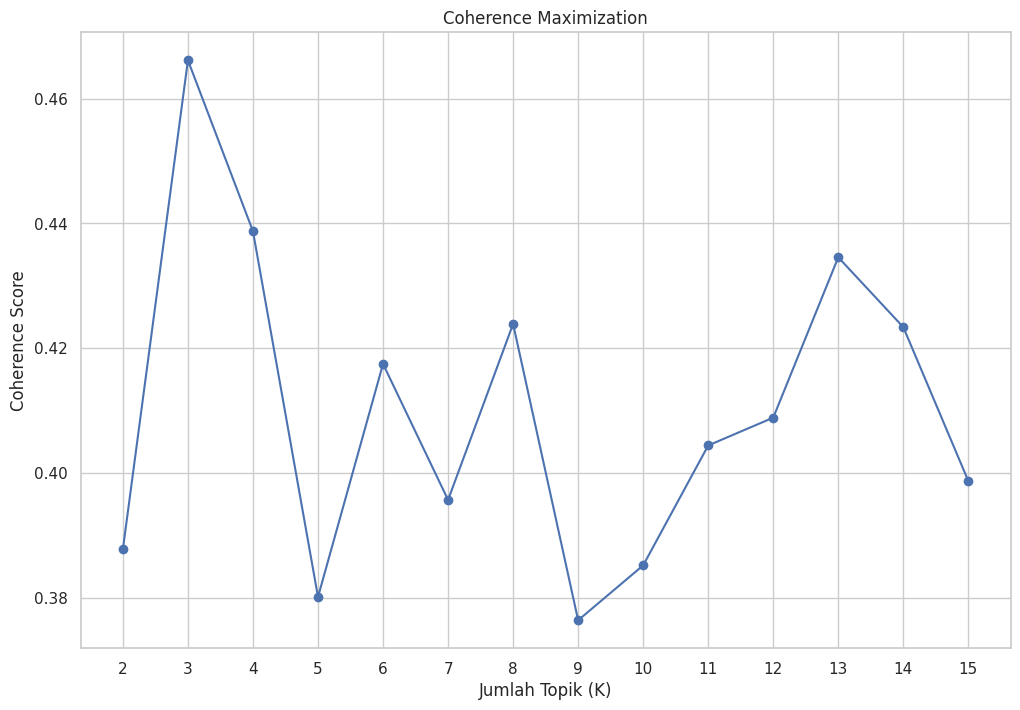

In [ ]:
x = range(START_K, LIMIT_K + 1, STEP_K)
plt.plot(x, coherence_values, marker='o', color='b')
plt.title("Coherence Maximization")
plt.xlabel("Jumlah Topik (K)")
plt.ylabel("Coherence Score")
plt.xticks(x)
plt.show()

## Final LDA Training


In [ ]:
K_OPTIMAL = 3

lda_final_model = model_list[x.index(K_OPTIMAL)]

df['lda_topic'] = [
    sorted(lda_final_model.get_document_topics(c), key=lambda x: x[1], reverse=True)[0][0]
    for c in corpus
]

In [ ]:
joblib.dump(lda_final_model, 'lda_model.joblib')

['lda_model.joblib']

## LDA Visualization & Initial Labeling

In [ ]:
pyLDAvis.enable_notebook()
vis = pyLDAvis.gensim_models.prepare(lda_final_model, corpus, id2word)

In [ ]:
vis

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
2     -0.241563 -0.036051       1        1  53.984964
0      0.156452 -0.165078       2        1  26.026216
1      0.085110  0.201130       3        1  19.988820, topic_info=          Term        Freq       Total Category  logprob  loglift
9    pelayanan  475.000000  475.000000  Default  30.0000  30.0000
15       cepat  299.000000  299.000000  Default  29.0000  29.0000
33       ramah  223.000000  223.000000  Default  28.0000  28.0000
42       kartu  369.000000  369.000000  Default  27.0000  27.0000
43    keluarga  365.000000  365.000000  Default  26.0000  26.0000
..         ...         ...         ...      ...      ...      ...
474     status   27.303776   52.782504   Topic3  -4.9743   0.9508
284   whatsapp   33.066132  105.231873   Topic3  -4.7828   0.4523
142      belum   34.179168  138.224849   Topic3  -4.7497   0.2127
118  kelurahan   30.516744  130.283879   Topic3  -4.8630   0.1586
341     gimana   30.466083  157.877299   Topic3  -4.8647  -0.0352

[184 rows x 6 columns], token_table=      Topic      Freq          Term
term                               
30        2  0.978158      adminduk
30        3  0.020812      adminduk
75        2  0.061785  administrasi
75        3  0.926776  administrasi
475       3  0.979626        ajukan
...     ...       ...           ...
29        2  0.608413         warga
29        3  0.159123         warga
721       2  0.947922         warna
284       1  0.684203      whatsapp
284       3  0.313593      whatsapp

[254 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[3, 1, 2])

In [ ]:
pyLDAvis.save_html(vis, 'lda_map.html')

# Phase 2: BERTopic (The Micro View)

## Embedding Generation

In [ ]:
embedding_model = SentenceTransformer(BERT_MODEL_NAME, device=device)

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

## Dimensionality Reduction (UMAP)

In [ ]:
umap_model = UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric='cosine',
    random_state=SEED
)

## Clustering (HDBSCAN)

In [ ]:
hdbscan_model = HDBSCAN(
    min_cluster_size=10,
    metric='euclidean',
    cluster_selection_method='eom',
    prediction_data=True
)

## Topic Reduction & Fine-Tuning

In [ ]:
topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    verbose=True,
    nr_topics="auto"
)

docs = df['text_for_bertopic'].tolist()
topics, probs = topic_model.fit_transform(docs)

df['bert_topic'] = topics

print(f"BERTopic selesai. Ditemukan {len(topic_model.get_topic_info())} topik (termasuk noise).")

2026-05-06 01:55:33,982 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/91 [00:00<?, ?it/s]

2026-05-06 01:55:36,434 - BERTopic - Embedding - Completed ✓
2026-05-06 01:55:36,435 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-06 01:56:02,140 - BERTopic - Dimensionality - Completed ✓
2026-05-06 01:56:02,141 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-06 01:56:02,303 - BERTopic - Cluster - Completed ✓
2026-05-06 01:56:02,304 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-05-06 01:56:02,425 - BERTopic - Representation - Completed ✓
2026-05-06 01:56:02,426 - BERTopic - Topic reduction - Reducing number of topics
2026-05-06 01:56:02,447 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-06 01:56:02,549 - BERTopic - Representation - Completed ✓
2026-05-06 01:56:02,551 - BERTopic - Topic reduction - Reduced number of topics from 60 to 38


BERTopic selesai. Ditemukan 38 topik (termasuk noise).


In [ ]:
# Melakukan reduksi topik
topic_model.reduce_topics(docs, nr_topics=7)

# PENTING: Update kolom bert_topic di dataframe dengan hasil yang sudah direduksi
df['bert_topic'] = topic_model.topics_

print(f"Topik telah direduksi. Cluster saat ini: {sorted(df['bert_topic'].unique())}")

2026-05-06 01:56:02,708 - BERTopic - Topic reduction - Reducing number of topics
2026-05-06 01:56:02,720 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-06 01:56:02,791 - BERTopic - Representation - Completed ✓
2026-05-06 01:56:02,794 - BERTopic - Topic reduction - Reduced number of topics from 38 to 7


Topik telah direduksi. Cluster saat ini: [np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


In [ ]:
topic_model.save(
    "model_bertopic",
    save_embedding_model=False,
    serialization="safetensors"
)

2026-05-06 02:08:34,302 - BERTopic - WARNING: You are saving a BERTopic model without explicitly defining an embedding model.If you are using a sentence-transformers model or a HuggingFace model supportedby sentence-transformers, please save the model by using a pointer towards that model.For example, `save_embedding_model='sentence-transformers/all-mpnet-base-v2'`


## BERTopic Visualization

In [ ]:
fig_1 = topic_model.visualize_topics()

In [ ]:
fig_2 = topic_model.visualize_barchart(top_n_topics=7)

In [ ]:
fig_3 = topic_model.visualize_documents(docs, embeddings=None)

In [ ]:
fig_1.show()

In [ ]:
fig_1.write_html("DistanceMap_BERT.html")

In [ ]:
fig_2.show()

In [ ]:
fig_3.show()

In [ ]:
fig_3.write_html("DocandTopic_BERT.html")

# Phase 3: Hybrid Blending

## Topic Mapping

In [ ]:
# Menghitung ulang matriks korelasi dengan data bert_topic yang sudah direduksi
ct_matrix = pd.crosstab(df['lda_topic'], df['bert_topic'])
ct_matrix_norm = ct_matrix.div(ct_matrix.sum(axis=1), axis=0)

## Keyword Anchoring Analysis

In [ ]:
def get_lda_keywords(model, n_words=5):
    topics = model.print_topics(num_words=n_words)
    keywords_dict = {}
    for idx, topic in topics:
        words = re.findall(r'"([^"]*)"', topic)
        keywords_dict[idx] = words
    return keywords_dict

def get_bertopic_keywords(model, n_words=5):
    info = model.get_topic_info()
    keywords_dict = {}
    for _, row in info.iterrows():
        topic_id = row['Topic']
        words = [word for word, score in model.get_topic(topic_id)[:n_words]]
        keywords_dict[topic_id] = words
    return keywords_dict

In [ ]:
lda_keys = get_lda_keywords(lda_final_model)
bert_keys = get_bertopic_keywords(topic_model)

In [ ]:
print("\n--- Perbandingan Keyword ---")
print(f"LDA Topik 0: {lda_keys.get(0)}")
print(f"BERT Topik 0: {bert_keys.get(0)}")


--- Perbandingan Keyword ---
LDA Topik 0: ['pelayanan', 'cepat', 'ramah', 'sentra_pelayanan', 'pelayanannya']
BERT Topik 0: ['pelayanan', 'dan', 'cepat', 'sangat', 'ramah']


## Correlation Heatmap

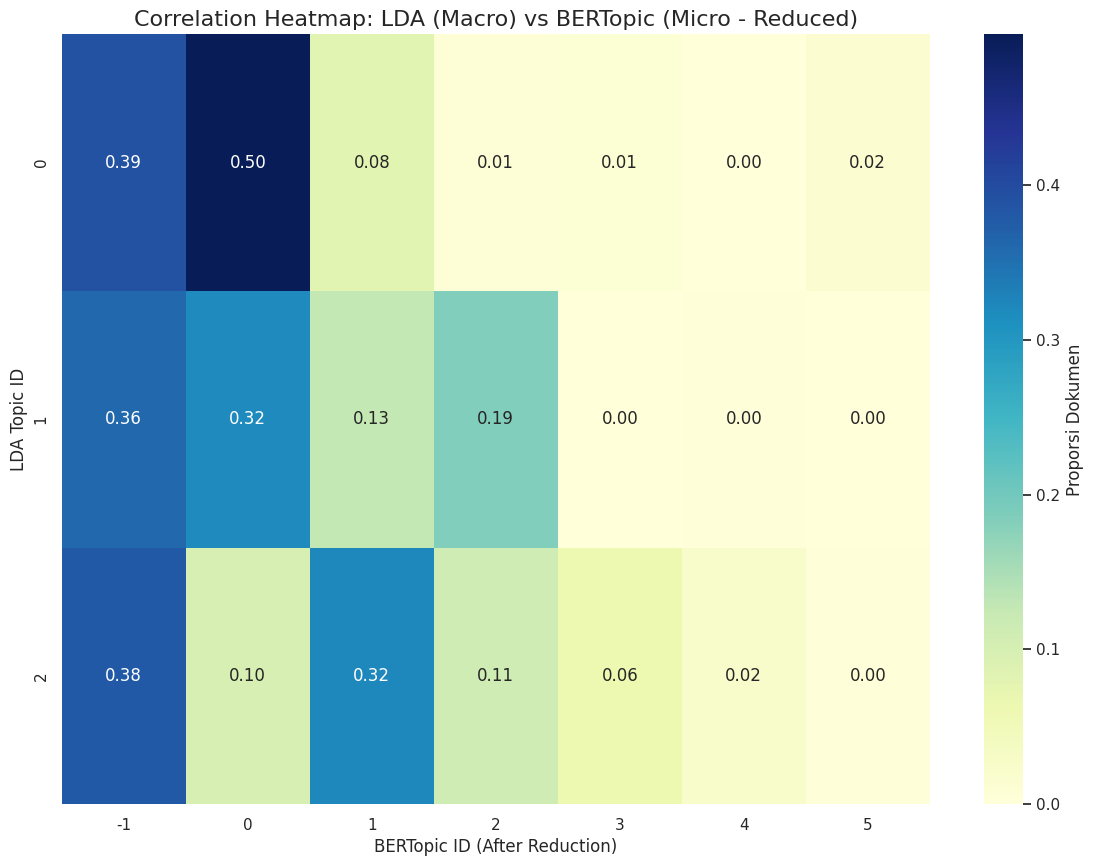

In [ ]:
plt.figure(figsize=(14, 10))
sns.heatmap(ct_matrix_norm,
            annot=True,
            fmt=".2f",
            cmap="YlGnBu",
            cbar_kws={'label': 'Proporsi Dokumen'})

plt.title("Correlation Heatmap: LDA (Macro) vs BERTopic (Micro - Reduced)", fontsize=16)
plt.xlabel("BERTopic ID (After Reduction)", fontsize=12)
plt.ylabel("LDA Topic ID", fontsize=12)
plt.show()

# Phase 4: Synthesis & Ensemble Evaluation

## High-Confidence Aduan Extraction (Ensemble Voting)

In [ ]:
def get_high_confidence_docs(df, lda_topic_id, bert_topic_id, n_samples=5):
    mask = (df['lda_topic'] == lda_topic_id) & (df['bert_topic'] == bert_topic_id)
    confidence_set = df[mask]

    print(f"Ditemukan {len(confidence_set)} aduan dengan konsensus tinggi antara LDA {lda_topic_id} & BERT {bert_topic_id}.")
    return confidence_set

In [ ]:
konsensus_list = []

for l_id in range(3):
    for b_id in range(10):
        res = get_high_confidence_docs(df, l_id, b_id)

        if len(res) > 0:
            konsensus_list.append({
                'lda_topic': l_id,
                'bert_topic': b_id,
                'jumlah_aduan': len(res)
            })

df_summary = pd.DataFrame(konsensus_list)
print(df_summary.sort_values(by='jumlah_aduan', ascending=False))

Ditemukan 453 aduan dengan konsensus tinggi antara LDA 0 & BERT 0.
Ditemukan 74 aduan dengan konsensus tinggi antara LDA 0 & BERT 1.
Ditemukan 7 aduan dengan konsensus tinggi antara LDA 0 & BERT 2.
Ditemukan 9 aduan dengan konsensus tinggi antara LDA 0 & BERT 3.
Ditemukan 0 aduan dengan konsensus tinggi antara LDA 0 & BERT 4.
Ditemukan 14 aduan dengan konsensus tinggi antara LDA 0 & BERT 5.
Ditemukan 0 aduan dengan konsensus tinggi antara LDA 0 & BERT 6.
Ditemukan 0 aduan dengan konsensus tinggi antara LDA 0 & BERT 7.
Ditemukan 0 aduan dengan konsensus tinggi antara LDA 0 & BERT 8.
Ditemukan 0 aduan dengan konsensus tinggi antara LDA 0 & BERT 9.
Ditemukan 179 aduan dengan konsensus tinggi antara LDA 1 & BERT 0.
Ditemukan 71 aduan dengan konsensus tinggi antara LDA 1 & BERT 1.
Ditemukan 104 aduan dengan konsensus tinggi antara LDA 1 & BERT 2.
Ditemukan 1 aduan dengan konsensus tinggi antara LDA 1 & BERT 3.
Ditemukan 2 aduan dengan konsensus tinggi antara LDA 1 & BERT 4.
Ditemukan 1 adua

## Sample Inspection

In [ ]:
# Mengecek jumlah topik unik yang tersedia setelah reduksi
current_bert_topics = sorted(df['bert_topic'].unique())
print(f"Cluster BERTopic saat ini (setelah reduksi): {current_bert_topics}")
print(f"Total cluster: {len(current_bert_topics)} (termasuk outlier -1)\n")

# Mencari pasangan dengan konsensus tertinggi secara otomatis dari data terbaru
# Kita cari yang jumlah aduannya terbanyak selain outlier
top_consensus = df[df['bert_topic'] != -1].groupby(['lda_topic', 'bert_topic']).size().idxmax()
L_ID, B_ID = top_consensus

ensemble_docs = get_high_confidence_docs(df, lda_topic_id=L_ID, bert_topic_id=B_ID)

print(f"\n--- Aduan Paling Valid Berdasarkan Konsensus Tertinggi (LDA {L_ID} & BERT {B_ID}) ---")
samples = ensemble_docs['comments'].sample(min(len(ensemble_docs), 5)).values
for i, s in enumerate(samples):
    print(f"{i+1}. {s}\n")

Cluster BERTopic saat ini (setelah reduksi): [np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Total cluster: 7 (termasuk outlier -1)

Ditemukan 454 aduan dengan konsensus tinggi antara LDA 2 & BERT 1.

--- Aduan Paling Valid Berdasarkan Konsensus Tertinggi (LDA 2 & BERT 1) ---
1. Selamat sore. Saya Mau bikin KK Dan KTP baru, Bisa Tolong arahan langkah2nya Bagaimana? Saya DM Mohon dibalas ya

2. Surabaya ngurus surat pindah ga bisa online ya?

3. mohon utuk petugasnya jika ada customer yg urgent untuk buat suket tolong lah d kasi solusi jgn bilang tidak bisa tidak bisa
harus kah komplain dulu baru d buatkan …

4. Mau tanya, cara urus pindah kk dalam kota gimana y?

5. Min, mau urus KTP medan di Surabaya bisa?



## Source Analysis (Cross-Platform Insight: IG, Maps, PlayStore)

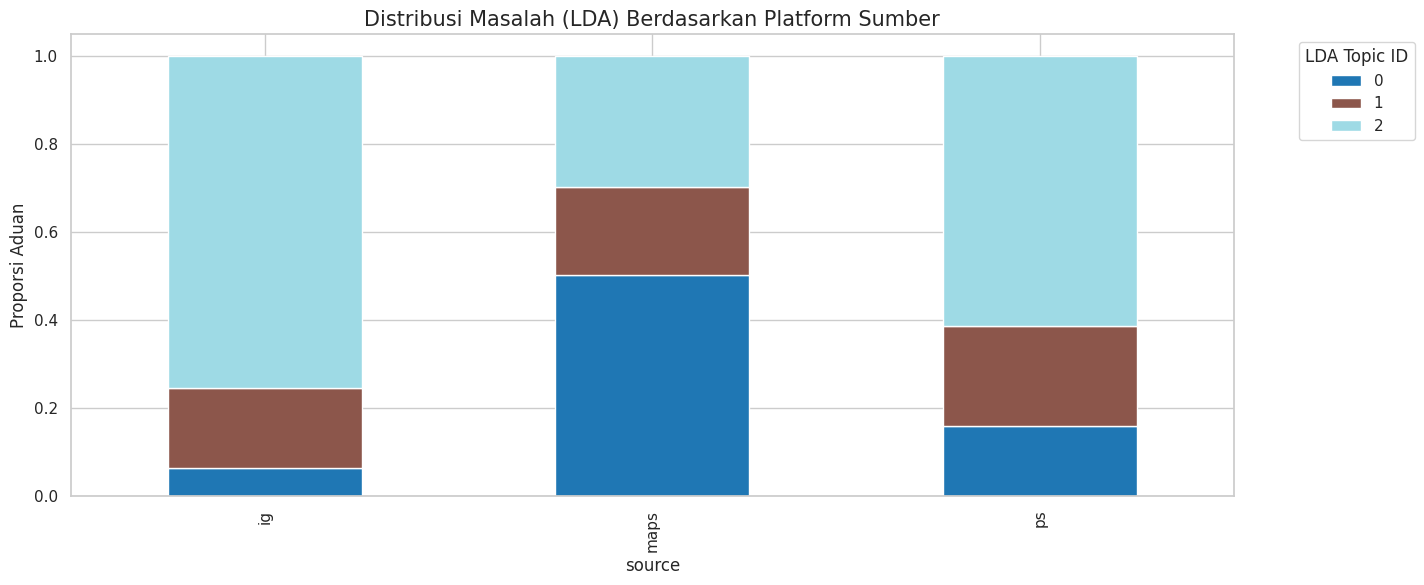

In [ ]:
plt.figure(figsize=(15, 6))
source_lda = pd.crosstab(df['source'], df['lda_topic'], normalize='index')
source_lda.plot(kind='bar', stacked=True, colormap='tab20', ax=plt.gca())
plt.title("Distribusi Masalah (LDA) Berdasarkan Platform Sumber", fontsize=15)
plt.ylabel("Proporsi Aduan")
plt.legend(title="LDA Topic ID", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# Volume Kontribusi Platform

=== Volume Kontribusi Platform ===
        Jumlah Aduan  Persentase (%)
source                              
maps            1631           56.53
ig              1148           39.79
ps               106            3.67


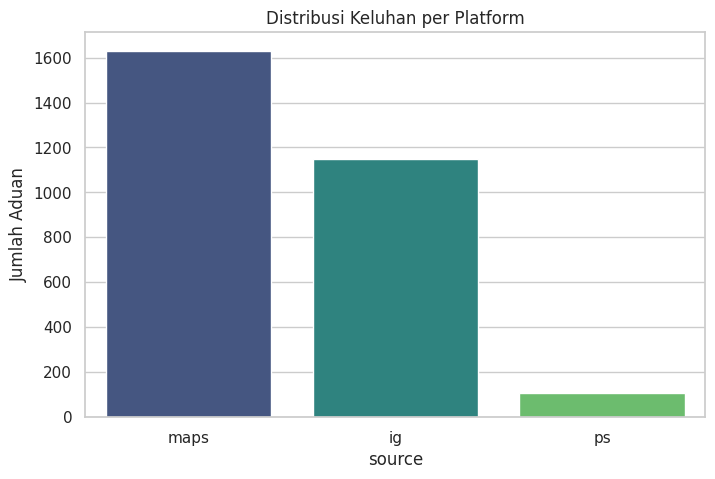

In [ ]:
platform_counts = df['source'].value_counts()
platform_pct = df['source'].value_counts(normalize=True) * 100

platform_summary = pd.DataFrame({
    'Jumlah Aduan': platform_counts,
    'Persentase (%)': platform_pct.round(2)
})

print("=== Volume Kontribusi Platform ===")
print(platform_summary)

plt.figure(figsize=(8, 5))
sns.barplot(x=platform_counts.index, y=platform_counts.values, palette='viridis')
plt.title('Distribusi Keluhan per Platform')
plt.ylabel('Jumlah Aduan')
plt.show()

# Final Output & Export

In [ ]:
#@title LDA Keywprd
n_words = 20

for topic_id in range(3):
    keywords = lda_final_model.show_topic(topic_id, topn=n_words)

    print(f"=== Keyword untuk Topic {topic_id + 1} ===")
    for word, weight in keywords:
        print(f"- {word} ({round(weight, 4)})")
    print("\n")

=== Keyword untuk Topic 1 ===
- pelayanan (0.06989999860525131)
- cepat (0.05310000106692314)
- ramah (0.04190000146627426)
- sentra_pelayanan (0.02590000070631504)
- pelayanannya (0.022700000554323196)
- pengurusan (0.022099999710917473)
- ktp (0.02199999988079071)
- bagus (0.021299999207258224)
- membantu (0.01730000041425228)
- mudah (0.017100000753998756)
- mengurus (0.017100000753998756)
- tidak (0.016599999740719795)
- petugas (0.015799999237060547)
- memuaskan (0.013799999840557575)
- jam (0.013399999588727951)
- orang (0.012900000438094139)
- warga (0.012600000016391277)
- pakal (0.01140000019222498)
- dispenduk (0.01080000028014183)
- nyaman (0.010499999858438969)


=== Keyword untuk Topic 2 ===
- tidak (0.05380000174045563)
- dm (0.029899999499320984)
- pelayanan (0.02930000051856041)
- layanan (0.025699999183416367)
- lontong_balap (0.01889999955892563)
- call (0.014700000174343586)
- center (0.011699999682605267)
- telpon (0.010599999688565731)
- dukcapil (0.009899999946355

In [ ]:
#@title BERTopic Keywords
from sklearn.feature_extraction.text import CountVectorizer

id_stopwords = [
    'yang', 'dan', 'di', 'itu', 'saya', 'ke', 'untuk', 'pada', 'dengan',
    'ini', 'bisa', 'mau', 'tidak', 'ada', 'adalah', 'sudah', 'akan', 'juga'
]

vectorizer_model = CountVectorizer(stop_words=id_stopwords)
topic_model.update_topics(docs, vectorizer_model=vectorizer_model)

In [ ]:
topic_info = topic_model.get_topic_info()
n_words = 20

print(f"Total Topik Ditemukan: {len(topic_info)}\n")

for index, row in topic_info.iterrows():
    topic_id = row['Topic']
    topic_name = row['Name']
    count = row['Count']

    prefix = "[OUTLIER]" if topic_id == -1 else f"[TOPIC {topic_id}]"

    keywords = topic_model.get_topic(topic_id)

    print(f"=== {prefix} {topic_name} ({count} dokumen) ===")
    if keywords:
        display_keywords = [f"{word} ({round(weight, 3)})" for word, weight in keywords[:n_words]]
        print(", ".join(display_keywords))
    else:
        print("Tidak ada keyword ditemukan.")
    print("-" * 30)

Total Topik Ditemukan: 7

=== [OUTLIER] -1_pelayanan_sangat_ktp_cepat (1091 dokumen) ===
pelayanan (0.041), sangat (0.035), ktp (0.032), cepat (0.03), ramah (0.025), nya (0.024), keluarga (0.022), ya (0.021), baik (0.021), kartu (0.021)
------------------------------
=== [TOPIC 0] 0_pelayanan_cepat_sangat_ramah (770 dokumen) ===
pelayanan (0.115), cepat (0.093), sangat (0.092), ramah (0.078), baik (0.071), bagus (0.059), sentra_pelayanan (0.059), joyoboyo (0.047), pelayanannya (0.042), pengurusan (0.041)
------------------------------
=== [TOPIC 1] 1_ktp_kartu_keluarga_pindah (599 dokumen) ===
ktp (0.074), kartu (0.06), keluarga (0.059), pindah (0.035), apa (0.034), kalau (0.031), cetak (0.031), dari (0.029), apakah (0.028), ngurus (0.027)
------------------------------
=== [TOPIC 2] 2_whatsapp_verifikasi_akun_call (271 dokumen) ===
whatsapp (0.075), verifikasi (0.067), akun (0.065), call (0.052), aplikasi (0.046), center (0.043), nomor (0.037), telpon (0.037), lontong_balap (0.036), l

## Labeling & Metadata

In [ ]:
lda_label_map = {
    1: "Kepuasan Layanan Tatap Muka",
    2: "Efektivitas Respon Aduan & Komunikasi",
    3: "Prosedur Administrasi & Teknis Dokumen Kependudukan"
}

bert_label_map = {
    -1: "Lain-lain",
    0: "Apresiasi Kinerja & Layanan Fisik",
    1: "Prosedur KTP, KK, & Perpindahan Domisili",
    2: "Masalah Teknis Aplikasi & Kanal Komunikasi",
    3: "Pencatatan Sipil (Akta Kelahiran/Kematian & Nikah)",
    4: "Prosedur Penggantian Foto KTP",
    5: "Pemutakhiran Biodata di Lokasi Spesifik"
}

df['lda_label'] = df['lda_topic'].map(lda_label_map)
df['bert_label'] = df['bert_topic'].map(bert_label_map)

def get_top_keywords(texts):
    words = re.findall(r'\w+', " ".join(texts.astype(str)).lower())
    words = [w for w in words if len(w) > 3] # Filter konjungsi
    return ", ".join([word for word, count in Counter(words).most_common(5)])

summary = df.groupby('source').agg({
    'source': 'count',
    'text_for_bertopic': get_top_keywords
}).rename(columns={'source': 'Total Aduan', 'text_for_bertopic': 'Keywords Dominan'})

summary['Persentase (%)'] = (summary['Total Aduan'] / len(df) * 100).round(2)

print("=== VOLUME PLATFORM ===")
print(summary[['Total Aduan', 'Persentase (%)', 'Keywords Dominan']])

ensemble = df.groupby(['source', 'lda_label', 'bert_label']).size().reset_index(name='Count')
ensemble = ensemble.sort_values(['source', 'Count'], ascending=[True, False])

top_ensemble = ensemble.groupby('source').head(2)

print("\n=== TOP TOPICS (ENSEMBLE) ===")
print(top_ensemble)

=== VOLUME PLATFORM ===
        Total Aduan  Persentase (%)                      Keywords Dominan
source                                                                   
ig             1148           39.79        tidak, bisa, saya, yang, kartu
maps           1631           56.53  pelayanan, tidak, saya, yang, sangat
ps              106            3.67     tidak, aplikasi, bisa, yang, akun

=== TOP TOPICS (ENSEMBLE) ===
   source                              lda_label  \
1      ig  Efektivitas Respon Aduan & Komunikasi   
5      ig  Efektivitas Respon Aduan & Komunikasi   
18   maps  Efektivitas Respon Aduan & Komunikasi   
14   maps  Efektivitas Respon Aduan & Komunikasi   
27     ps  Efektivitas Respon Aduan & Komunikasi   
26     ps  Efektivitas Respon Aduan & Komunikasi   

                                    bert_label  Count  
1                                    Lain-lain    330  
5     Prosedur KTP, KK, & Perpindahan Domisili    257  
18    Prosedur KTP, KK, & Perpindahan Domi

In [ ]:
df.to_csv('dispenduk_final_labeled.csv', index=False)

In [ ]:
topic_model.visualize_topics().write_html("bertopic_viz.html")
topic_model.visualize_hierarchy().write_html("bertopic_hierarchy.html")
topic_model.visualize_barchart().write_html("bertopic_barchart.html")